# Saturácia kyslíkom- Numerický aj kategorický

In [1]:
pip install xgboost catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 7.1 MB/s eta 0:00:00


In [5]:
pip install shap==0.44.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.7/535.7 kB 3.3 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from math import sqrt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVR
import xgboost as xgb
import catboost as cb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from mlxtend.evaluate import bias_variance_decomp
from sklearn.pipeline import make_pipeline
%matplotlib inline



In [3]:
sns.set(style="whitegrid")

In [55]:
data = pd.read_excel("data_no_missing.xlsx")
original_data = data.copy()
data

,Derivation cohort,LOS,Death,Severity,Black,White,Asian,Latino,MI,PVD,...,Glucose,AST,ALT,WBC,Lympho,IL6,Ferritin,CrctProtein,Procalcitonin,Troponin
0,1,3,0,6,1,0,0,0,0,0,...,132,54.000,26.0,7.4,1.2,48.2000,1962.0,27.3000,0.3000,0.00999
1,1,6,0,4,0,1,0,0,0,0,...,115,135.000,243.0,5.9,1.1,5.3000,3043.0,11.1000,1.6000,0.01000
2,1,1,0,2,1,0,0,0,0,1,...,182,23.000,19.0,7.1,2.9,3.9999,87.0,0.8000,0.0999,0.00999
3,1,3,0,5,1,0,0,0,0,0,...,159,45.000,33.0,7.1,0.6,3.9999,3464.0,3.0000,1.3000,0.23000
4,1,14,0,3,0,0,0,1,0,0,...,127,84.000,43.0,3.6,0.4,11.8000,994.0,14.5000,0.2000,0.01000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,0,3,0,1,1,0,0,0,0,0,...,110,19.999,12.0,14.7,3.1,10.8000,254.0,1.9000,0.3000,0.01000
868,0,2,0,2,0,0,0,0,0,0,...,150,51.000,35.0,6.2,0.8,70.9000,184.0,4.1000,0.1000,0.01000
869,0,2,0,1,0,0,0,1,0,0,...,131,58.000,81.0,7.0,1.5,3.9999,73.0,0.4999,0.1000,0.01000
870,0,6,0,5,0,0,0,0,0,1,...,224,36.000,15.0,6.6,1.2,5.4000,750.0,21.1000,0.3000,0.01000


In [56]:
# Renaming columns
data = data.rename(columns={
    'LOS': 'Length_of_stay',
    'MI': 'Myocardial_infarction',
    'PVD': 'Per_vascular_dis',
    'CHF': 'Cong_heart_failure',
    'CVD': 'Cardiovascular_dis',
    'DEMENT': 'Dementia',
    'COPD': 'Chronic_obst_pulm_dis',
    'DM Complicated': 'Diabetes_mel_complicated',
    'DM Simple': 'Diabetes_mel_simple',
    'Renal Disease': 'Renal_dis',
    'All CNS': 'All_CNS',
    'Pure CNS': 'Pure_CNS',
    'OldOtherNeuro': 'Other_neuro_dis',
    'OtherBrnLsn': 'Other_brain_lesions',
    'Age.1': 'Age_number',
    'AgeScore': 'Age_category',
    'OsSats': 'Oxygen_sat',
    'Temp': 'Temperature',
    'MAP': 'Mean_art_press',
    'Plts': 'Platelets',
    'INR': 'Inter_norm_ratio',
    'BUN': 'Blood_urea_nitr',
    'WBC': 'White_blood_cells',
    'CrctProtein': 'CRP'
})


In [57]:
data['Per_vascular_dis'] = data['Per_vascular_dis'].replace(2, 1)

In [58]:
# Convert the column to integers
data['Oxygen_sat'] = data['Oxygen_sat'].astype(int)

In [59]:
data_copy = data.copy()

## Popis cieľového atribútu

<ipython-input-11-934c1b8d4a08>:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(new_labels, fontsize=12)  # Adjust fontsize as needed


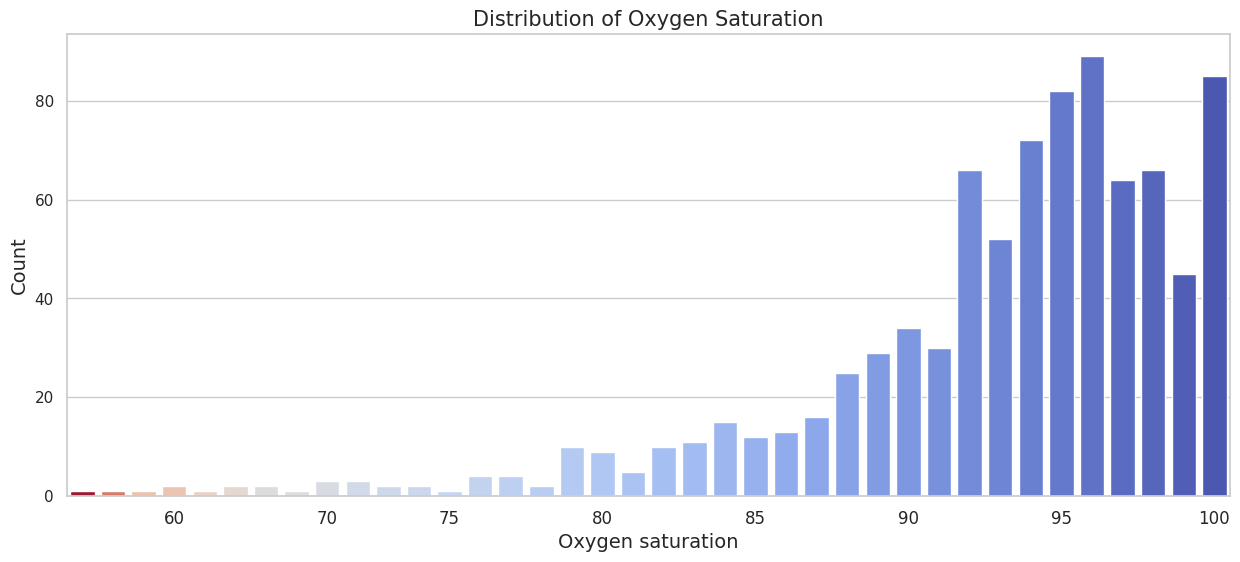

In [11]:
plt.figure(figsize=(15, 6))
sns.countplot(data=data, x="Oxygen_sat", hue="Oxygen_sat", palette="coolwarm_r", legend=False)

# Get current axis
ax = plt.gca()

# Get the tick labels and their corresponding positions
labels = [label.get_text() for label in ax.get_xticklabels()]
positions = ax.get_xticks()

# Since we want to start from 1 and show every 5th label, we adjust our approach
start_pos = next(pos for pos, label in zip(positions, labels) if int(label) >= 1)

# Adjust labels to show every 5th starting from 1, and increase their size
new_labels = ['' if int(label) % 5 != 0 else label for label in labels]
ax.set_xticklabels(new_labels, fontsize=12)  # Adjust fontsize as needed

# Adding a title to the x-axis and y-axis
ax.set_xlabel("Oxygen saturation", fontsize=14)  # Customize the title and fontsize
ax.set_ylabel("Count", fontsize=14)  # Customize the title and fontsize
plt.title("Distribution of Oxygen Saturation", fontsize=15)
plt.show()


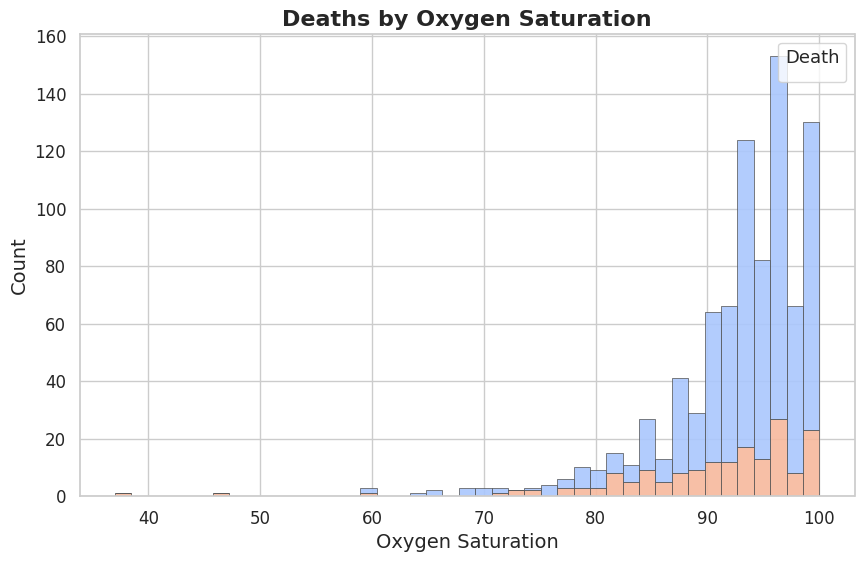

In [12]:
plt.figure(figsize=(10, 6))
plt.title('Deaths by Oxygen Saturation', fontsize=16, fontweight='bold')

sns.histplot(
    x='Oxygen_sat',
    hue='Death',
    multiple="stack",
    data=data,
    palette="coolwarm",
    edgecolor='.3',
    linewidth=.5,
    alpha=0.9
)

plt.xlabel('Oxygen Saturation', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Death', title_fontsize='13', fontsize='12', loc='upper right')

plt.show()
#

<Axes: title={'center': 'Deaths by Oxygen saturation'}, xlabel='Oxygen_sat', ylabel='Count'>

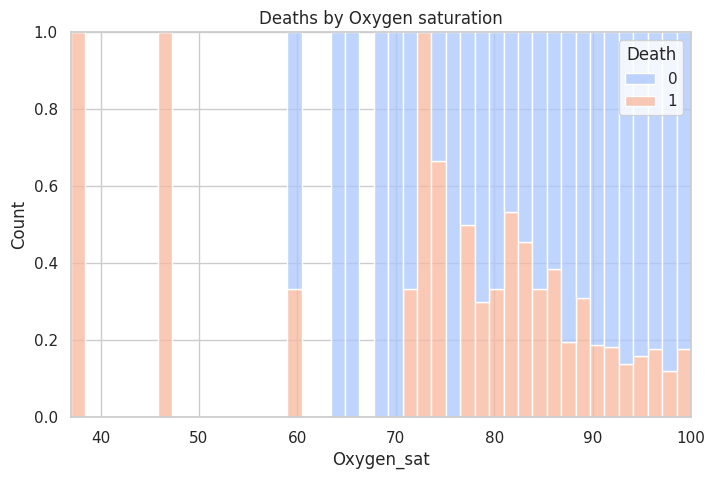

In [13]:
plt.figure(figsize=(8,5))
plt.title('Deaths by Oxygen saturation')
sns.histplot(x='Oxygen_sat', hue='Death',multiple="fill", data=data, palette="coolwarm")

<Axes: xlabel='Oxygen_sat', ylabel='Mean_art_press'>

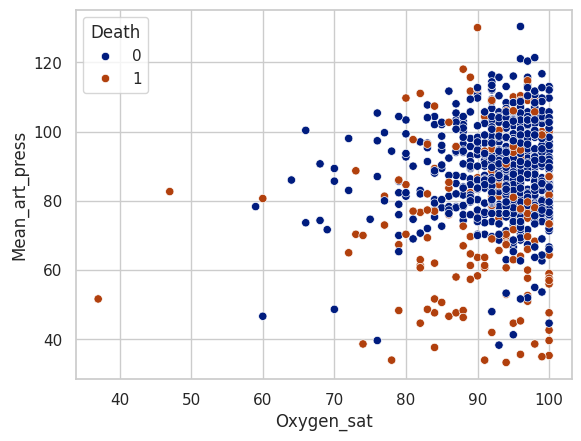

In [14]:
sns.scatterplot(x="Oxygen_sat", y="Mean_art_press", hue="Death", data=data, palette="dark")

<ipython-input-15-db3ca15bd8cb>:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="Oxygen_sat", y="CRP",  data=data, palette="dark")


<Axes: xlabel='Oxygen_sat', ylabel='CRP'>

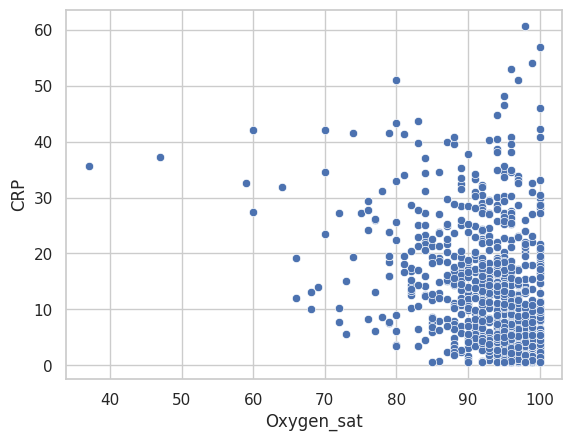

In [15]:
sns.scatterplot(x="Oxygen_sat", y="CRP",  data=data, palette="dark")

<ipython-input-16-1b7864f2cf71>:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="Oxygen_sat", y="Creatinine",  data=data, palette="dark")


<Axes: xlabel='Oxygen_sat', ylabel='Creatinine'>

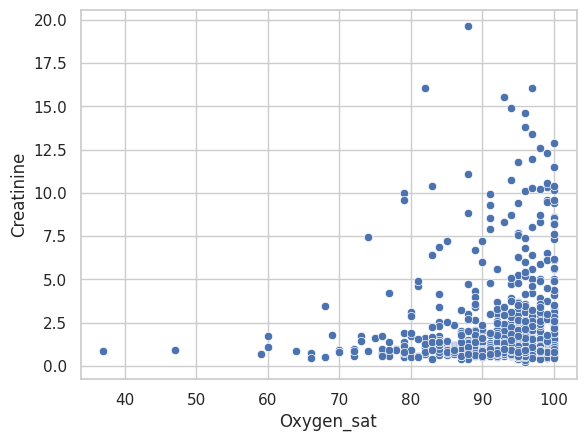

In [16]:
sns.scatterplot(x="Oxygen_sat", y="Creatinine",  data=data, palette="dark")

# Rozdelenie atribútov na numerické a kategorické

In [17]:
numeric_features = data.columns[data.nunique() > 10]

print("Columnns that contain more than 10 values:\n", numeric_features)
print("Number of nuemrical features:", numeric_features.size)

Columnns that contain more than 10 values:
 Index(['Length_of_stay', 'Severity', 'Age2', 'Oxygen_sat', 'Temperature',
       'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio',
       'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT',
       'White_blood_cells', 'Lympho', 'IL6', 'Ferritin', 'CRP',
       'Procalcitonin', 'Troponin'],
      dtype='object')
Number of nuemrical features: 22


In [18]:
categorical_features = data.columns[data.nunique() <=4]
categorical_features = categorical_features.drop("Death")
print("Columnns that contain less than 10 values:\n", categorical_features)
print("Number of categorical features:", categorical_features.size)

Columnns that contain less than 10 values:
 Index(['Derivation cohort', 'Black', 'White', 'Asian', 'Latino',
       'Myocardial_infarction', 'Per_vascular_dis', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_category', 'PltsScore',
       'CrtnScore'],
      dtype='object')
Number of categorical features: 24


# Log transformácia (data_copy) numerických atribútov kvôli štatistickým testom

### Výber numerických atribútov

In [19]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['Severity', 'CrtnScore','PltsScore','Age_category']) #drop items that show categories, scores, etc.

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Length_of_stay', 'Age2', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'IL6', 'Ferritin', 'CRP', 'Procalcitonin', 'Troponin']
21


## 2. Log transformation of DATA COPY

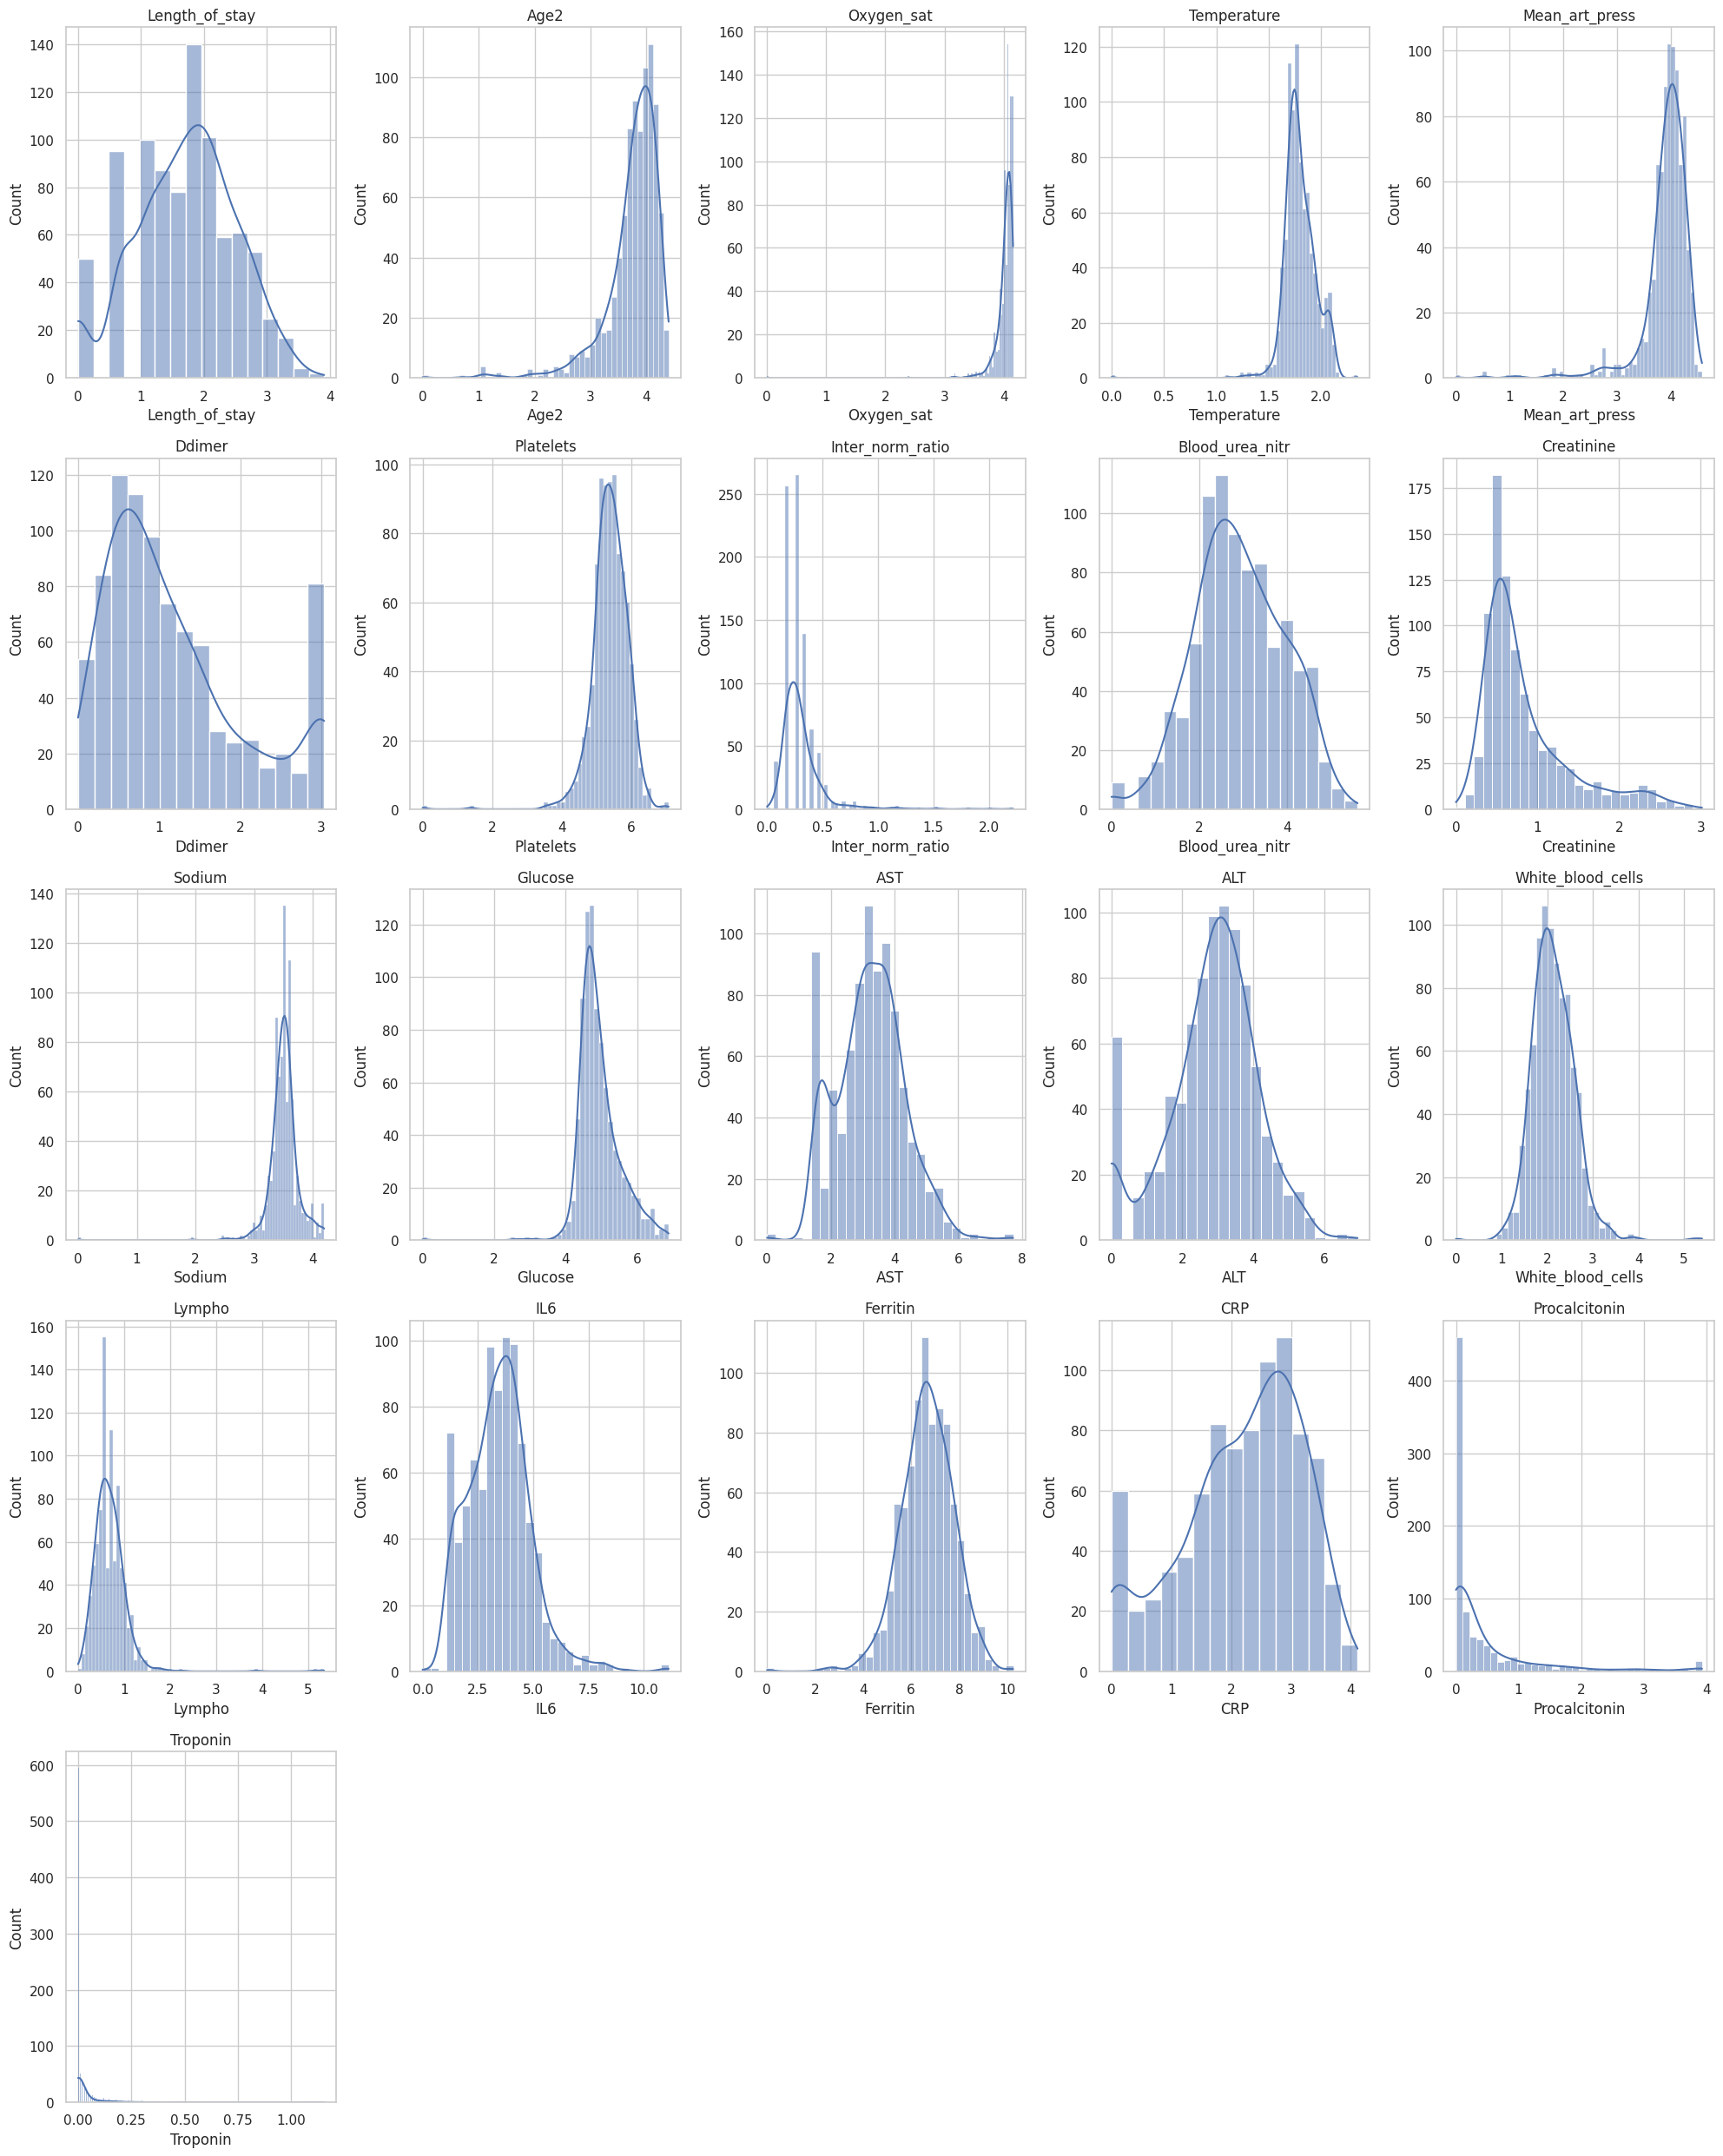

In [20]:

data_copy[selectedColumns] = data_copy[selectedColumns] + 1 - data_copy[selectedColumns].min()

# Apply log transformation
data_copy[selectedColumns] = np.log(data_copy[selectedColumns])

num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

# Flatten the axes if there is more than one row
axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data_copy[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

# Remove any empty subplots
for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE

## Pearsonov koeficient pre vplyv numerických atribútov na numerický cieľový atribút

<ipython-input-21-bc182ac41480>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
<ipython-input-21-bc182ac41480>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')


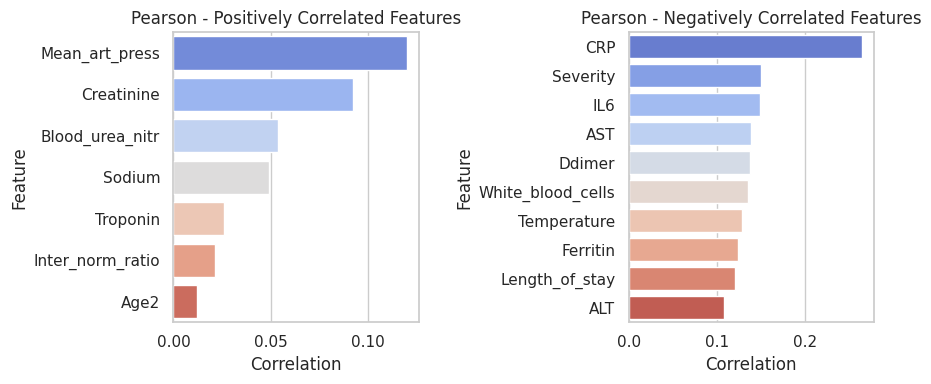

In [21]:
target_feature = 'Oxygen_sat'

# Calculate Spearman correlation coefficients with the target variable
pearson_corr_with_target = data_copy[numeric_features].corr(method='pearson')[target_feature].drop(target_feature)

# Split correlations into positive and negative
positive_correlations = pearson_corr_with_target[pearson_corr_with_target > 0]
negative_correlations = pearson_corr_with_target[pearson_corr_with_target < 0]

# Sort the correlations by their absolute values in descending order
positive_correlations_sorted = positive_correlations.sort_values(ascending=False)
negative_correlations_sorted = negative_correlations.abs().sort_values(ascending=False)

# Extract the top correlated features (both positively and negatively)
n_top_features = 10

# Plot the most positively correlated features
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Pearson - Positively Correlated Features')

# Plot the most negatively correlated features
plt.subplot(1, 2, 2)
sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Pearson - Negatively Correlated Features')

plt.tight_layout()
plt.show()

## Spearmanov koeficient

<ipython-input-22-29a57c85ea40>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
<ipython-input-22-29a57c85ea40>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')


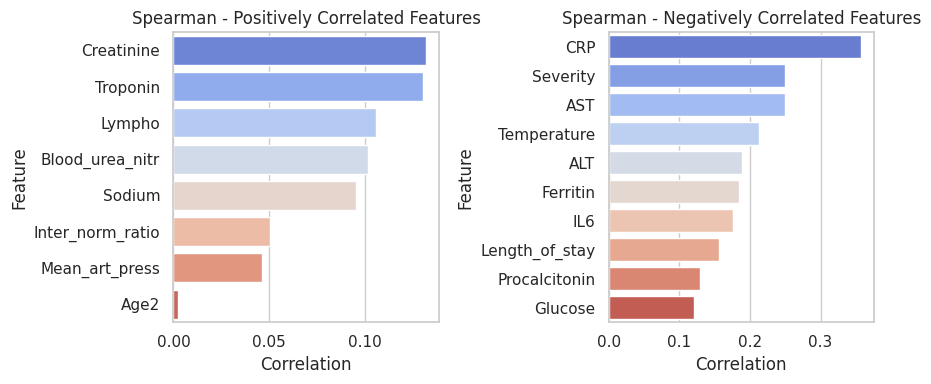

In [22]:
target_feature = 'Oxygen_sat'

# Calculate Spearman correlation coefficients with the target variable
corr_with_target = data_copy[numeric_features].corr(method='spearman')[target_feature].drop(target_feature)

# Split correlations into positive and negative
positive_correlations = corr_with_target[corr_with_target > 0]
negative_correlations = corr_with_target[corr_with_target < 0]

# Sort the correlations by their absolute values in descending order
positive_correlations_sorted = positive_correlations.sort_values(ascending=False)
negative_correlations_sorted = negative_correlations.abs().sort_values(ascending=False)

# Extract the top correlated features (both positively and negatively)
n_top_features = 10

# Plot the most positively correlated features
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Spearman - Positively Correlated Features')

# Plot the most negatively correlated features
plt.subplot(1, 2, 2)
sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Spearman - Negatively Correlated Features')

plt.tight_layout()
plt.show()

## Kendallov koeficient pre zistenie vplyvu kategorických atr. na numerický

<ipython-input-23-c794ba11a4ec>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
<ipython-input-23-c794ba11a4ec>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')


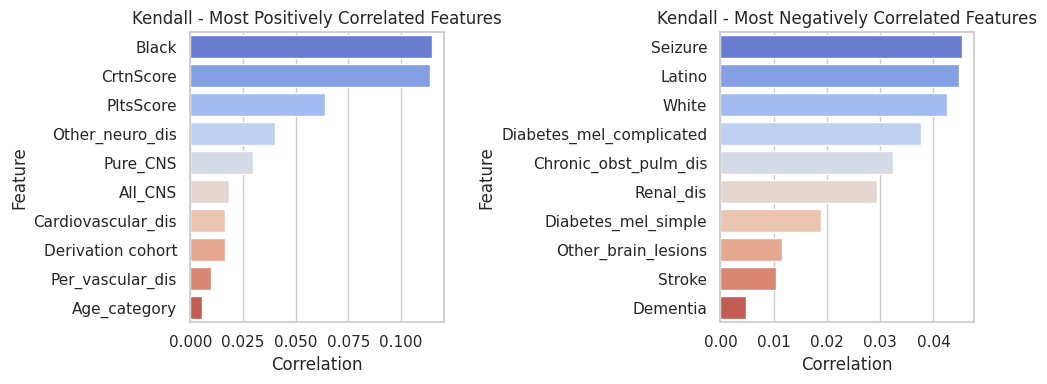

In [23]:
target_feature = 'Oxygen_sat'
# Calculate Kendall's tau correlation coefficients with the 'LOS' target variable
corr_with_target = data_copy[categorical_features].apply(lambda x: x.corr(data_copy[target_feature], method='kendall'))

# Split correlations into positive and negative
positive_correlations = corr_with_target[corr_with_target > 0]
negative_correlations = corr_with_target[corr_with_target < 0]

positive_correlations_sorted = positive_correlations.sort_values(ascending=False)
negative_correlations_sorted = negative_correlations.abs().sort_values(ascending=False)

# Extract the top correlated features (both positively and negatively)
n_top_features = 10

# Plot the most positively correlated features
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Kendall - Most Positively Correlated Features')

# Plot the most negatively correlated features
plt.subplot(1, 2, 2)
sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Kendall - Most Negatively Correlated Features')

plt.tight_layout()
plt.show()


## ANOVA pre vplyv kategorických atr. na numerický

In [26]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame(data_copy)

# Perform ANOVA test for numeric features
f_stat, p_values_anova = f_classif(df[categorical_features], df['Oxygen_sat'])

# Display p-values in ascending order
print("ANOVA Test Results:")
print("Feature\t\tP-Value")
sorted_p_values_anova = sorted(zip(categorical_features, p_values_anova), key=lambda x: x[1])
for feature, p_value_anova in sorted_p_values_anova:
    print(f"{feature}\t\t{p_value_anova}")

# Visualize boxplots for significant features
significant_features = [feature for feature, p_value in sorted_p_values_anova if p_value < 0.05]



ANOVA Test Results:
Feature		P-Value
Seizure		3.8958291175938155e-06
Age_category		0.02756275407252205
OldSyncope		0.05062997573505979
CrtnScore		0.08575251041714216
Diabetes_mel_complicated		0.16319402364382898
Asian		0.18547198806311999
Derivation cohort		0.3090379231426152
Diabetes_mel_simple		0.35943957229325507
Dementia		0.4712412037877307
Cong_heart_failure		0.5568211470575456
Pure_CNS		0.5643067190985602
All_CNS		0.5948238285566423
Black		0.6068879855005699
Cardiovascular_dis		0.6762267441480401
Latino		0.7358637597631847
Stroke		0.7877334995231967
Chronic_obst_pulm_dis		0.7884256075142093
White		0.8060716568256062
Renal_dis		0.8240351681976998
Per_vascular_dis		0.862501638304267
PltsScore		0.9417680275867765
Myocardial_infarction		0.9618155650542068
Other_brain_lesions		0.9950170987632724
Other_neuro_dis		0.9973899732587433


## Boxplots na pôvodných dátach

<ipython-input-25-96fb452dd993>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Oxygen_sat', x=feature, data=data, palette="coolwarm", ax=axes[i])
<ipython-input-25-96fb452dd993>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Oxygen_sat', x=feature, data=data, palette="coolwarm", ax=axes[i])


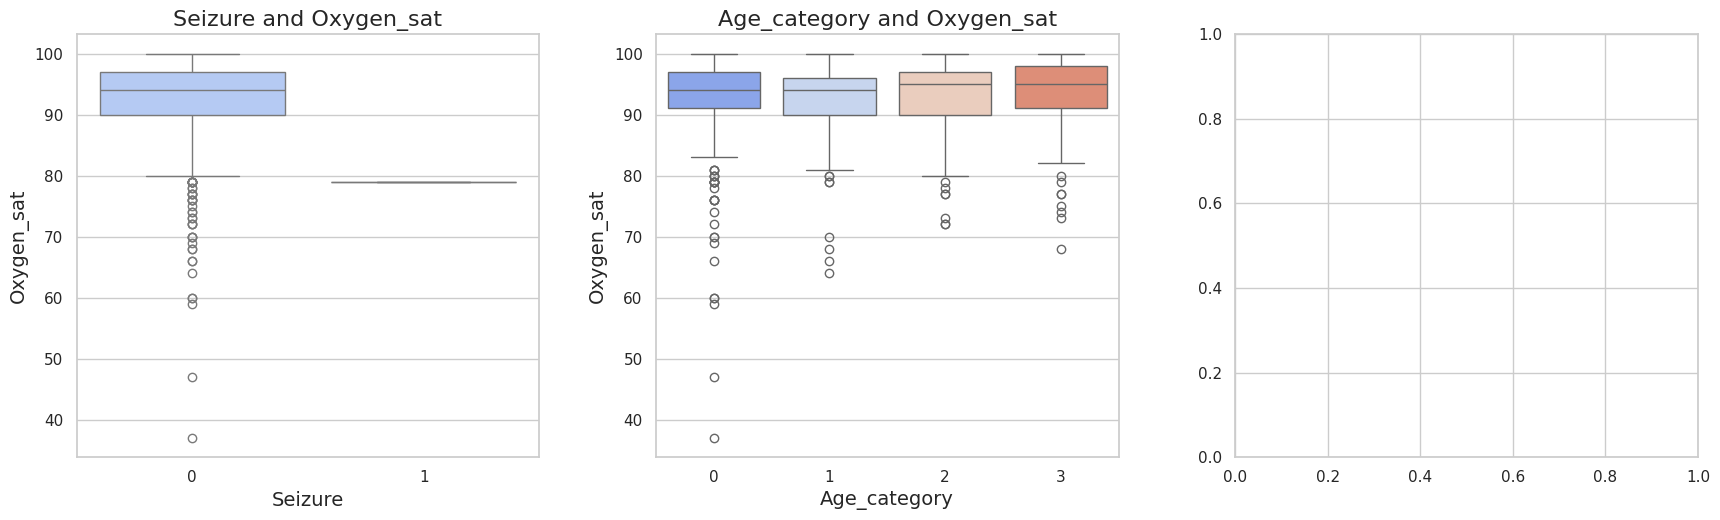

In [25]:
top_3_features = significant_features[:3]  # Selecting the top 3 features for visualization

# Setup the matplotlib figure for a 1x3 subplot layout, all in one row
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Iterate over the top 3 significant features and create boxplots for each
for i, feature in enumerate(top_3_features):
    sns.boxplot(y='Oxygen_sat', x=feature, data=data, palette="coolwarm", ax=axes[i])
    axes[i].set_title(f'{feature} and Oxygen_sat', fontsize=16)
    axes[i].set_xlabel(feature, fontsize=14)
    axes[i].set_ylabel('Oxygen_sat', fontsize=14)

plt.tight_layout(pad=3.0)

plt.show()

In [27]:
feature_names=X.columns

NameError: name 'X' is not defined

# Normalizácia - data - pre modelovanie

### Výber numerických atribútov na normalizáciu, okrem cieľovej premennej atd


In [60]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['Oxygen_sat', 'CrtnScore','PltsScore','Age_category']) #drop items that show categories, scores, etc.

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Length_of_stay', 'Severity', 'Age2', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'IL6', 'Ferritin', 'CRP', 'Procalcitonin', 'Troponin']
21


Numeric features distributions

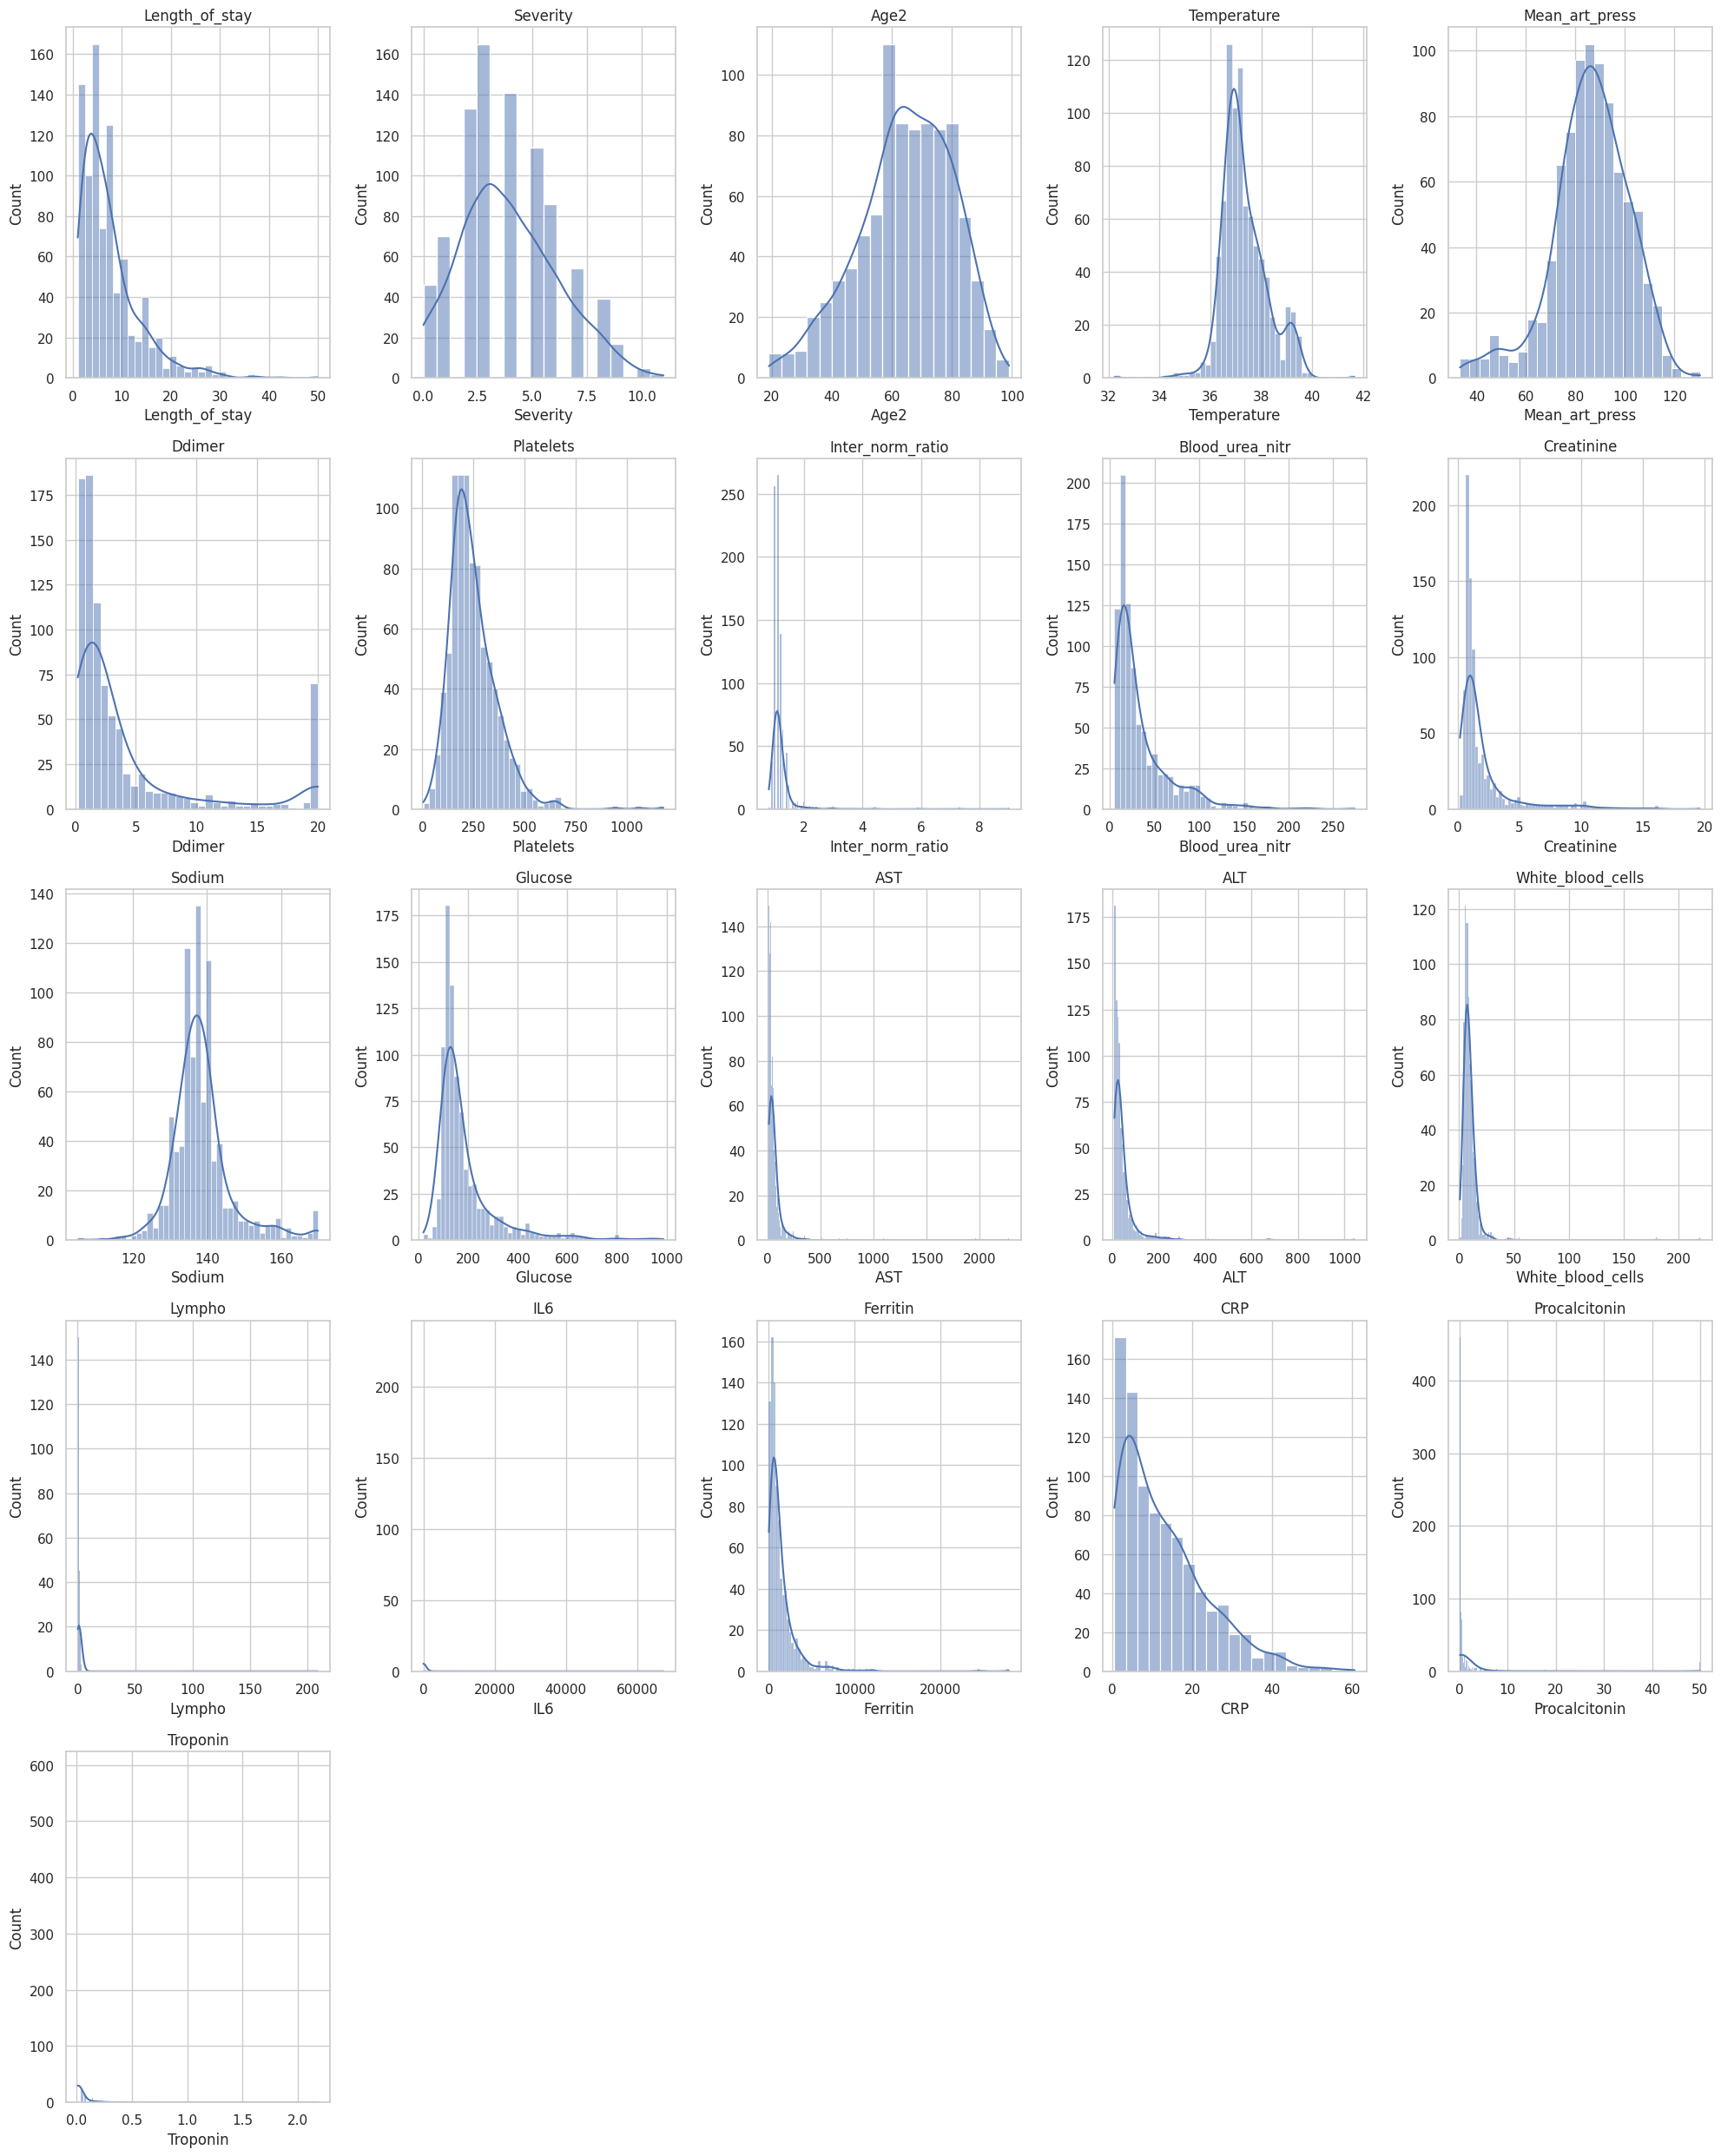

In [29]:
num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

# Flatten the axes if there is more than one row
axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

# Remove any empty subplots
for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Standard Scaler

In [61]:
from sklearn.preprocessing import StandardScaler, RobustScaler
# Select the columns we want to normalize
columns_to_normalize = selectedColumns

# Create a new DataFrame for the columns to normalize
data_to_normalize = data[columns_to_normalize]

# Normalize using Min-Max scaling
standard_scaler = StandardScaler()
data_to_normalize_minmax = standard_scaler.fit_transform(data_to_normalize)

# Update the original DataFrame with the normalized values
data[columns_to_normalize] = data_to_normalize_minmax

data.head(5)

,Derivation cohort,Length_of_stay,Death,Severity,Black,White,Asian,Latino,Myocardial_infarction,Per_vascular_dis,...,Glucose,AST,ALT,White_blood_cells,Lympho,IL6,Ferritin,CRP,Procalcitonin,Troponin
0,1,-0.735599,0,0.945490,1,0,0,0,0,0,...,-0.425913,-0.091402,-0.295404,-0.194421,-0.048318,-0.067319,0.292748,1.341902,-0.251006,-0.253109
1,1,-0.241675,0,0.047377,0,1,0,0,0,0,...,-0.554445,0.576364,3.179095,-0.338855,-0.059171,-0.081546,0.841690,-0.156141,-0.079523,-0.253046
2,1,-1.064882,0,-0.850735,1,0,0,0,0,1,...,-0.047879,-0.346967,-0.407485,-0.223308,0.136191,-0.081977,-0.659395,-1.108601,-0.277402,-0.253109
3,1,-0.735599,0,0.496434,1,0,0,0,0,0,...,-0.221774,-0.165598,-0.183324,-0.223308,-0.113439,-0.081977,1.055478,-0.905163,-0.119096,1.139518
4,1,1.075455,0,-0.401679,0,0,0,1,0,0,...,-0.463717,0.155919,-0.023209,-0.560319,-0.135146,-0.079390,-0.198812,0.158263,-0.264197,-0.253046


## Vytvorenie pomocných "dummies" atribútov pre kategorické atribúty

In [62]:
# get_dummies to create dummy variables for each categorical column
data = pd.get_dummies(data, columns=['CrtnScore', 'PltsScore', 'Age_category'], prefix=['CrtnScore', 'PltsScore', 'AgeScore'])

data.head(5)

,Derivation cohort,Length_of_stay,Death,Severity,Black,White,Asian,Latino,Myocardial_infarction,Per_vascular_dis,...,CrtnScore_0,CrtnScore_1,CrtnScore_2,PltsScore_0,PltsScore_1,PltsScore_2,AgeScore_0,AgeScore_1,AgeScore_2,AgeScore_3
0,1,-0.735599,0,0.945490,1,0,0,0,0,0,...,True,False,False,True,False,False,False,False,False,True
1,1,-0.241675,0,0.047377,0,1,0,0,0,0,...,True,False,False,True,False,False,False,True,False,False
2,1,-1.064882,0,-0.850735,1,0,0,0,0,1,...,True,False,False,True,False,False,False,True,False,False
3,1,-0.735599,0,0.496434,1,0,0,0,0,0,...,False,False,True,True,False,False,False,False,True,False
4,1,1.075455,0,-0.401679,0,0,0,1,0,0,...,True,False,False,True,False,False,True,False,False,False


In [32]:
data.columns

Index(['Derivation cohort', 'Length_of_stay', 'Death', 'Severity', 'Black',
       'White', 'Asian', 'Latino', 'Myocardial_infarction', 'Per_vascular_dis',
       'Cong_heart_failure', 'Cardiovascular_dis', 'Dementia',
       'Chronic_obst_pulm_dis', 'Diabetes_mel_complicated',
       'Diabetes_mel_simple', 'Renal_dis', 'All_CNS', 'Pure_CNS', 'Stroke',
       'Seizure', 'OldSyncope', 'Other_neuro_dis', 'Other_brain_lesions',
       'Age2', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer',
       'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine',
       'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'IL6',
       'Ferritin', 'CRP', 'Procalcitonin', 'Troponin', 'CrtnScore_0',
       'CrtnScore_1', 'CrtnScore_2', 'PltsScore_0', 'PltsScore_1',
       'PltsScore_2', 'AgeScore_0', 'AgeScore_1', 'AgeScore_2', 'AgeScore_3'],
      dtype='object')

In [63]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5).fit(data_copy[numeric_features], data_copy['Oxygen_sat'])
important_features = [feature for feature, coef in zip(numeric_features, lasso.coef_) if coef != 0]
print('Important features:', important_features)


Important features: ['Oxygen_sat', 'Platelets', 'Glucose', 'IL6', 'Ferritin']


In [64]:
X = data.drop(columns=["Death","Severity", "Oxygen_sat"]) #

y = data["Oxygen_sat"]

In [65]:
# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and fitting the Lasso Regression model
lasso = Lasso(alpha=0.1)  # Alpha is the regularization strength
lasso.fit(X_train, y_train)

# Making predictions
y_pred = lasso.predict(X_test)

# Calculating Mean Squared Error (MSE) on test set
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Get the coefficients and corresponding feature names
coefficients = lasso.coef_
feature_names = [f'Feature {i}' for i in range(X.shape[1])]


Mean Squared Error: 35.16715151926509


## LASSO REGRESSION

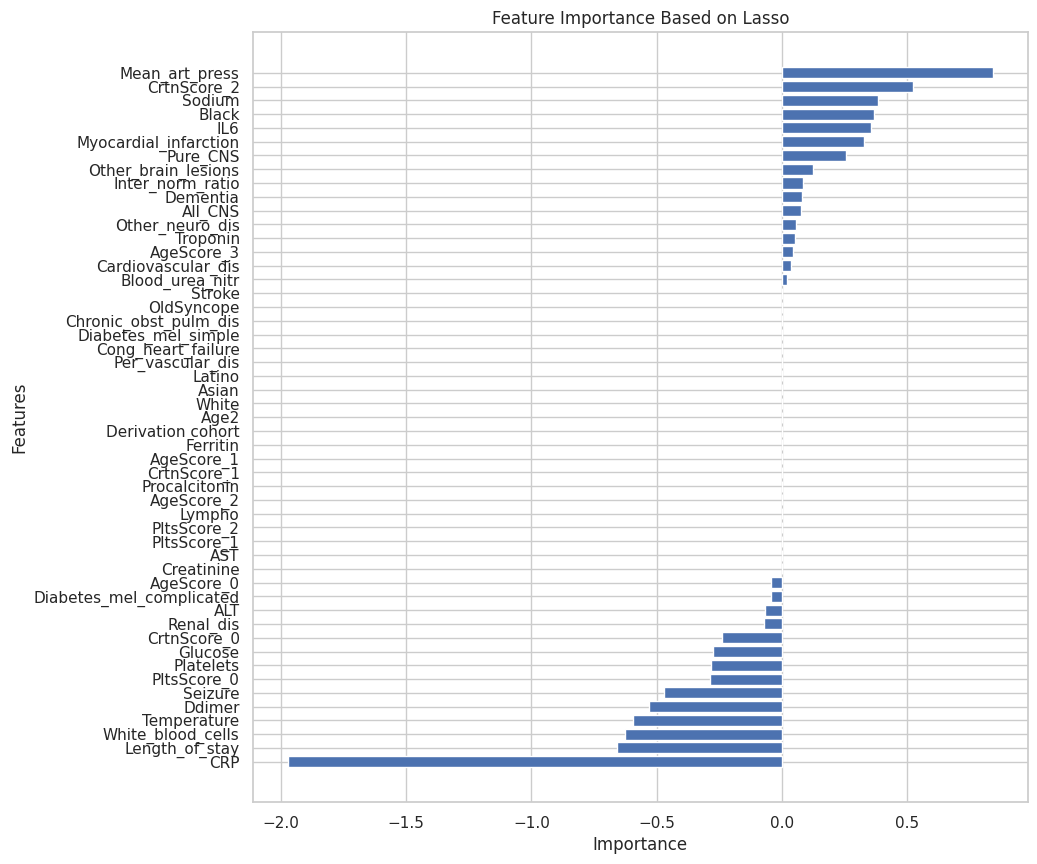

In [66]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardizing the features if not already done
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# Getting the coefficients
coefficients = lasso.coef_

# Sort feature importance coefficients
sorted_indices = np.argsort(coefficients)

# Get sorted feature names and importance values
sorted_features = np.array(X_train.columns)[sorted_indices]
sorted_importance = coefficients[sorted_indices]

# Plotting
plt.figure(figsize=(10,10))
plt.barh(sorted_features, sorted_importance)
plt.grid(True)
plt.title("Feature Importance Based on Lasso")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

## ANOVA pre vplyv numerických atr. na kategorický

# PREDICTING OXYGEN SATURATION

In [77]:
X = data.drop(columns=["Death","Severity","Oxygen_sat"])

y = data["Oxygen_sat"]

In [78]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.2, random_state=42)
print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)

Train_x : (697, 51)
Test_x : (175, 51)
Train_y : (697,)
Test_y : (175,)


# Všetky modely - porovnanie podľa MAE

In [79]:
# Models
models = [
    ('LinearRegression', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('RandomForest', RandomForestRegressor()),
    ('LGBMRegressor', LGBMRegressor()),
    ('SVR', SVR()),
    ('KNN', KNeighborsRegressor()),
    ('XGBRegressor', xgb.XGBRegressor()),
    ('CatBoostRegressor', cb.CatBoostRegressor(verbose=0)),  # verbose=0 to keep the output clean

]

results_table = []

for name, model in models:
    if name == 'SequentialNN':
        # Create and train the Sequential model
        model = create_sequential_model((train_x.shape[1],))
        history = model.fit(train_x, train_y, epochs=10, batch_size=32, verbose=0)
        predictions = model.predict(test_x).flatten()  # Flatten predictions
    else:
        # Train the model
        model.fit(train_x, train_y)
        # Make predictions
        predictions = model.predict(test_x)

    # Calculate metrics
    mae = mean_absolute_error(test_y, predictions)
    mse = mean_squared_error(test_y, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(test_y, predictions)

    # Store results
    results_table.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    })


results_df = pd.DataFrame(results_table)
results_df = results_df.round(3)
results_df.sort_values(by='MAE', inplace=True)
print(results_df)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000691 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2285
[LightGBM] [Info] Number of data points in the train set: 697, number of used features: 45
[LightGBM] [Info] Start training from score 92.757532
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

## SVR

Mean Absolute Error: 3.925736204564532
MSE: 33.168496920573695
RMSE: 5.759209747923207


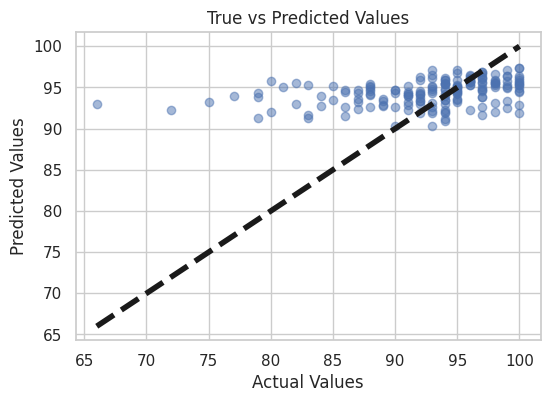

In [82]:
# Create and fit the SVR model
svr = SVR()
svr.fit(train_x, train_y)

# Predictions for the SVR model (predictions are in transformed scale)
y_pred = svr.predict(test_x)

# Evaluate the SVR model in the original scale
mse = mean_squared_error(test_y, y_pred)
mape = mean_absolute_percentage_error(test_y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Plotting true vs predicted values in original scale
plt.figure(figsize=(6, 4))
plt.scatter(test_y, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.plot([min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], [min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], 'k--', lw=4)
plt.show()


## SVR C=1, epsilon=0.2)

Mean Absolute Error: 3.9228297421728584
Mean Squared Error: 33.134996356964955
R^2 Score: 0.04717440053328459


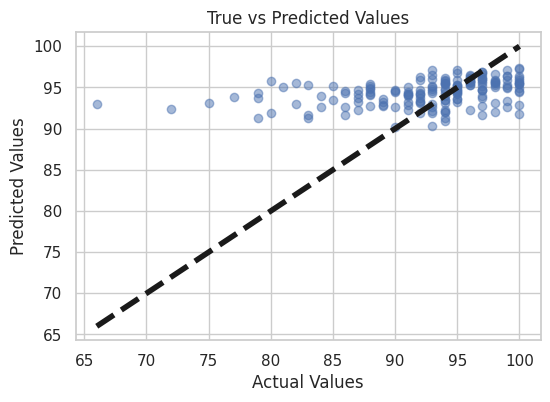

In [85]:
model = SVR(C=1, epsilon=0.2)

# Fit the model
model.fit(train_x, train_y)

# Predict
y_pred = model.predict(test_x)

# Evaluate the model
print(f"Mean Absolute Error: {mean_absolute_error(test_y, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(test_y, y_pred)}")
print(f"R^2 Score: {r2_score(test_y, y_pred)}")

# Plotting true vs predicted values
plt.figure(figsize=(6, 4))
plt.scatter(test_y, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.plot([min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], [min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], 'k--', lw=4)
plt.show()



## CatBoost Regressor

Mean Absolute Error: 4.26950457068347
MSE: 35.71977813994412
RMSE: 5.9766025583055225
R²: -0.027153244634543716


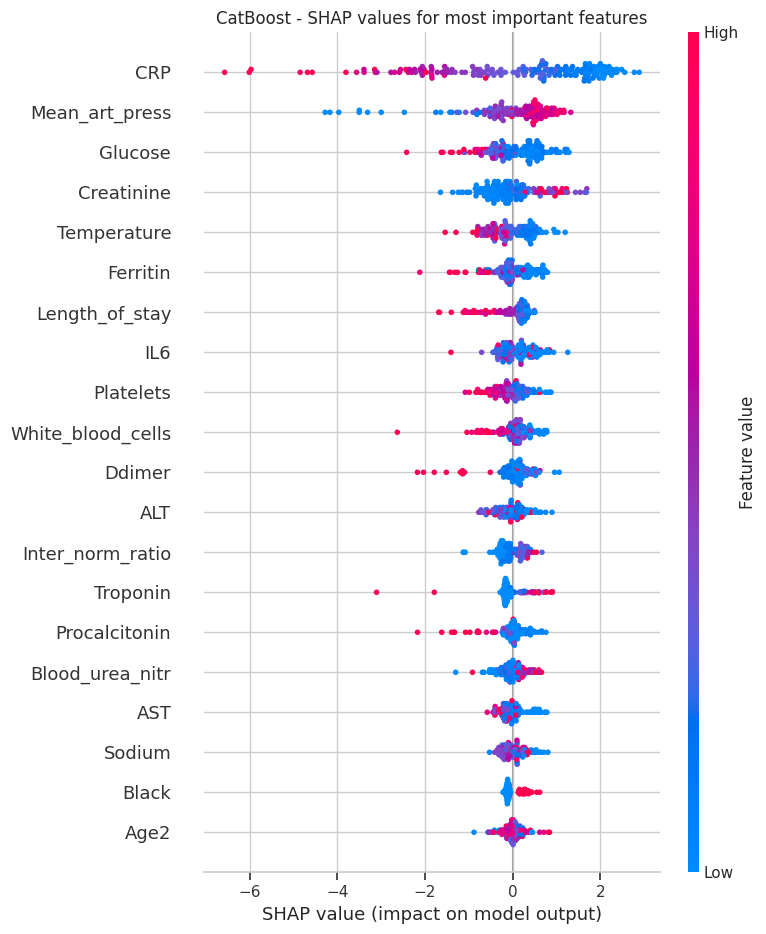

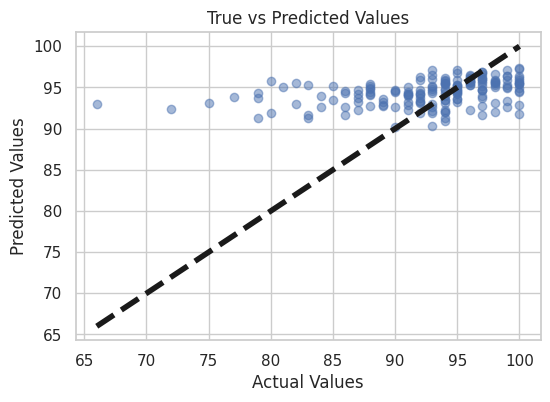

In [89]:
import shap

cat_regressor = cb.CatBoostRegressor(verbose=0)
cat_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = cat_regressor.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, pred_y)
print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(cat_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
plt.figure(figsize=(3, 7))
plt.title("CatBoost - SHAP values for most important features")
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Plotting true vs predicted values
plt.figure(figsize=(6, 4))
plt.scatter(test_y, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")

plt.plot([min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], [min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], 'k--', lw=4)
plt.show()

## Random Forest Regressor - 3 min

Mean Absolute Error: 4.377257142857143
MSE: 38.107472
RMSE: 6.173124978485371


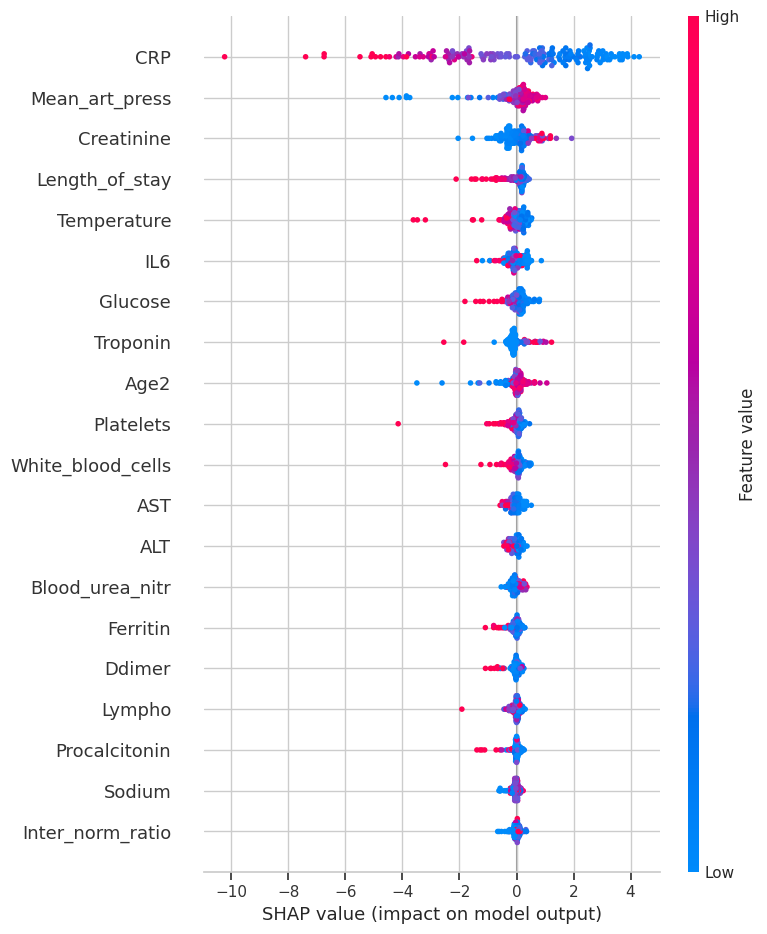

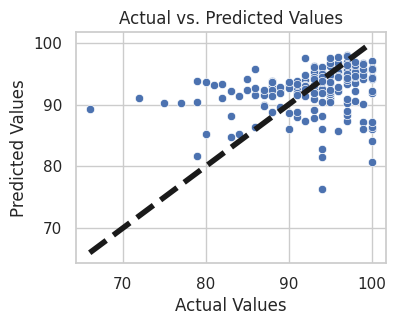

In [90]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import shap
from math import sqrt

# Create a Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = rf_regressor.predict(test_x)
#
# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)

mae = mean_absolute_error(test_y, pred_y)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")


# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(rf_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4,3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], [min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], 'k--', lw=4)
plt.show()

## KNN Regressor

Mean Absolute Error: 4.273142857142857
KNN MSE: 33.3872
KNN MAPE: 0.047793156050646136
KNN RMSE: 5.778165798936545


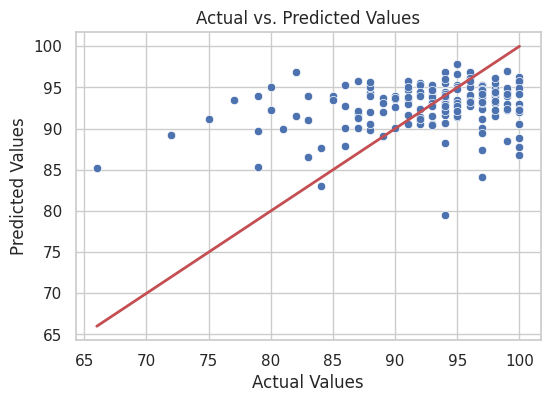

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Model for Regression
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train, y_train)

# Predictions for KNN model
knn_predictions = knn.predict(X_test)

# Evaluate the KNN model using MSE and MAPE
knn_mse = mean_squared_error(y_test, knn_predictions)
knn_mape = mean_absolute_percentage_error(y_test, knn_predictions)
knn_rmse = np.sqrt(knn_mse)  # RMSE
mae = mean_absolute_error(test_y, knn_predictions)

print(f"Mean Absolute Error: {mae}")

print(f'KNN MSE: {knn_mse}')
print(f'KNN MAPE: {knn_mape}')
print(f'KNN RMSE: {knn_rmse}')

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=knn_predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=2)  # Ideal line for perfect predictions
plt.show()

## KNN Regressor development with different n_neighbors

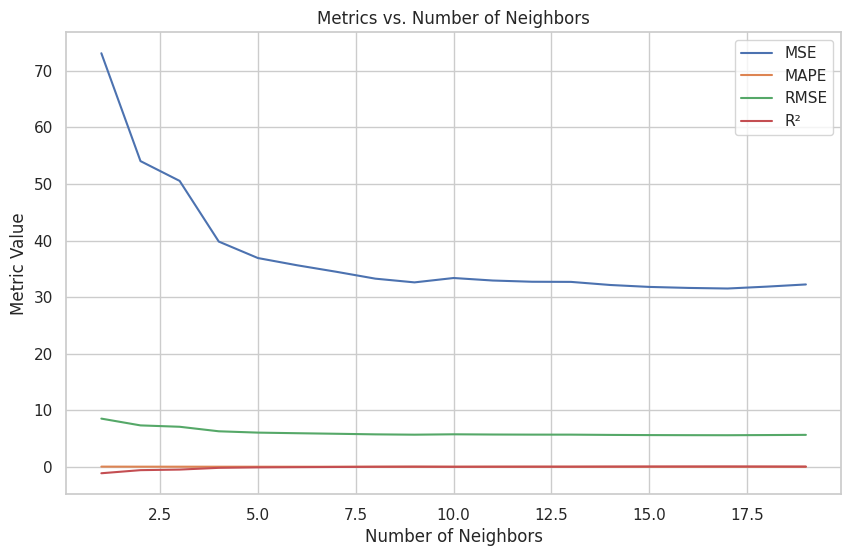

In [92]:
n_neighbors_range = range(1, 20)

# Lists to store evaluation metrics
mse_values = []
mape_values = []
rmse_values = []
r2_values = []

# Iterate over different n_neighbors values
for n_neighbors in n_neighbors_range:
    # Train KNN model
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)

    # Predictions for KNN model
    knn_predictions = knn.predict(X_test)

    # Evaluate the KNN model
    mse = mean_squared_error(y_test, knn_predictions)
    mape = mean_absolute_percentage_error(y_test, knn_predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, knn_predictions)

    # Append metrics to lists
    mse_values.append(mse)
    mape_values.append(mape)
    rmse_values.append(rmse)
    r2_values.append(r2)

# Plot the development of metrics for different n_neighbors
plt.figure(figsize=(10, 6))

plt.plot(n_neighbors_range, mse_values, label='MSE')
plt.plot(n_neighbors_range, mape_values, label='MAPE')
plt.plot(n_neighbors_range, rmse_values, label='RMSE')
plt.plot(n_neighbors_range, r2_values, label='R²')

plt.xlabel('Number of Neighbors')
plt.ylabel('Metric Value')
plt.title('Metrics vs. Number of Neighbors')
plt.legend()
plt.grid(True)
plt.show()


## Linear Regression

Mean Absolute Error: 4.454535881960406
MSE: 37.33600194657396
RMSE: 6.1103192998871965


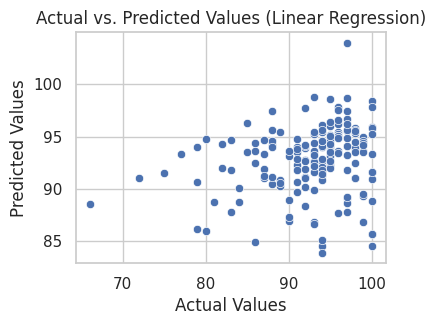

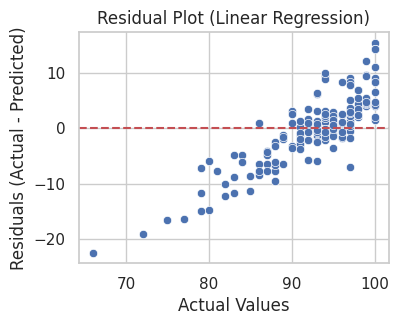

In [95]:
linear_regressor = LinearRegression()
linear_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = linear_regressor.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, pred_y)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4,3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (Linear Regression)")
plt.show()

# Residual plot
residuals = test_y - pred_y
plt.figure(figsize=(4,3))
sns.scatterplot(x=test_y, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Linear Regression)")
plt.show()



## XGB Regressor

Mean Absolute Error: 4.6363846261160715
MSE: 43.034372663126724
RMSE: 6.560058891742263


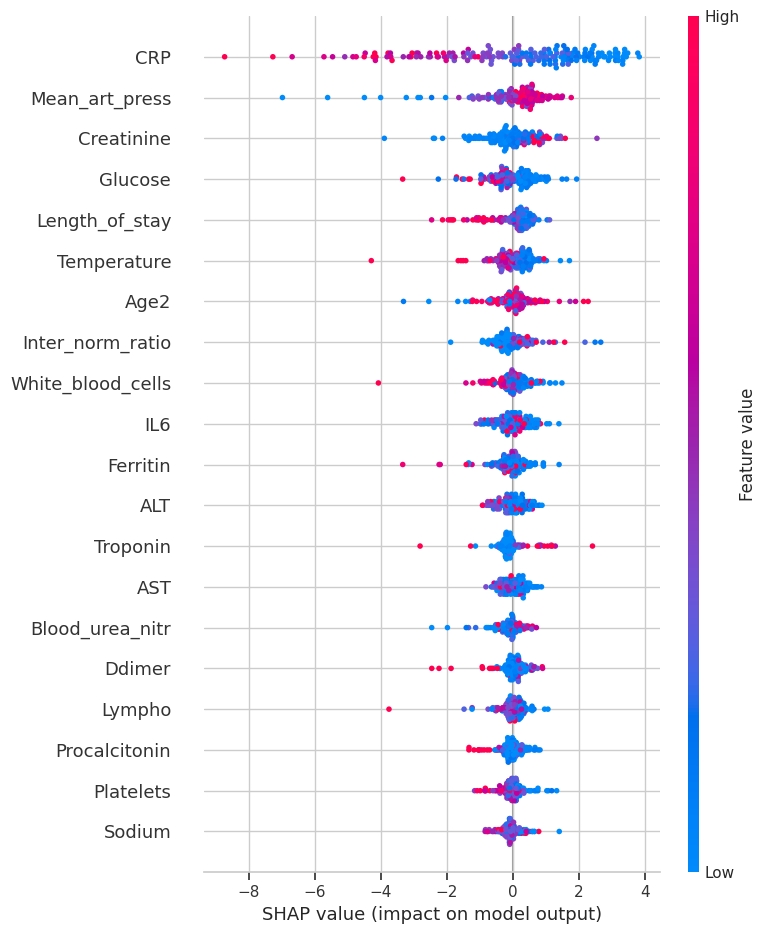

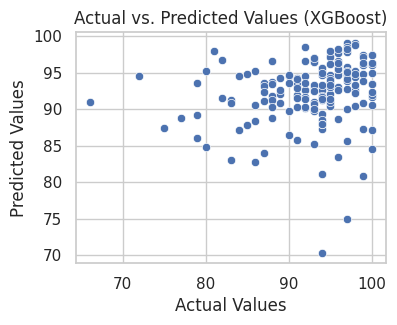

In [97]:
import xgboost as xgb

# Create an XGBoost regression model
xgb_regressor = xgb.XGBRegressor(objective ='reg:squarederror', random_state=42)
xgb_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = xgb_regressor.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, pred_y)
print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(xgb_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
plt.figure(figsize=(3, 7))
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4, 3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (XGBoost)")
plt.show()


## ElasticNet

Mean Absolute Error: 4.258132026122573
MSE: 33.90748801398195
RMSE: 5.823013653940882


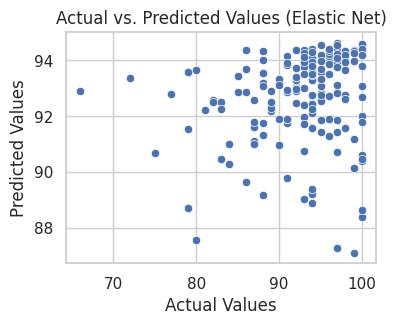

In [99]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Create an Elastic Net model
elastic_net = ElasticNet(alpha=1, l1_ratio=0.9)  # Adjust alpha and l1_ratio as needed
elastic_net.fit(train_x, train_y)

# Make predictions on the test set
pred_y = elastic_net.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, pred_y)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")


# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4,3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (Elastic Net)")
plt.show()
